In [1]:
input_tce_csv_file = "/pdo/astronet-data/data/properties/tces-sector87.csv"
tess_data_dir = "/pdo/astronet-data/data/fits/sector-87/"
astro_id_to_inspect = 30081274102

In [2]:
import os
os.chdir('/pdo/users/pablomer/Astronet-Triage')
import sys
sys.path.insert(0, "/pdo/users/pablomer/Astronet-Triage")


In [3]:
from typing import Optional
import pandas as pd
import numpy as np
from astronet.preprocess import preprocess
import matplotlib.pyplot as plt

tce_table = pd.read_csv(input_tce_csv_file, header=0, low_memory=False)
print(f'Loaded {len(tce_table)}, downsampling to 1 id {astro_id_to_inspect}')
tce = tce_table[tce_table["Astro ID"] == astro_id_to_inspect].iloc[0]
print(tce.to_string())

def get_lightcurve(astro_id: int, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }
    matching_tces = tce_table[tce_table["Astro ID"] == astro_id] # tce_table.where(tce_table["Astro ID"] == astro_id)
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e
    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf
    return preprocess.read_and_process_light_curve(
        tess_data_dir,
        aperture_key_map[aperture],
        tce.File,
        tce.MinT,
        tce.MaxT,
    )

Loaded 4824, downsampling to 1 id 30081274102
TIC ID                                              300812741
SMass                                                     0.7
SRad                                                 0.697547
Tmag                                                  10.0534
planetno                                                    2
Epoc                                              1328.692691
Per                                                 11.307119
Depth                                              285.445342
Dur                                                  0.150726
SRadEst                                                   NaN
Astro ID                                          30081274102
File        /pdo/astronet-data/data/fits/sector-87/astrone...


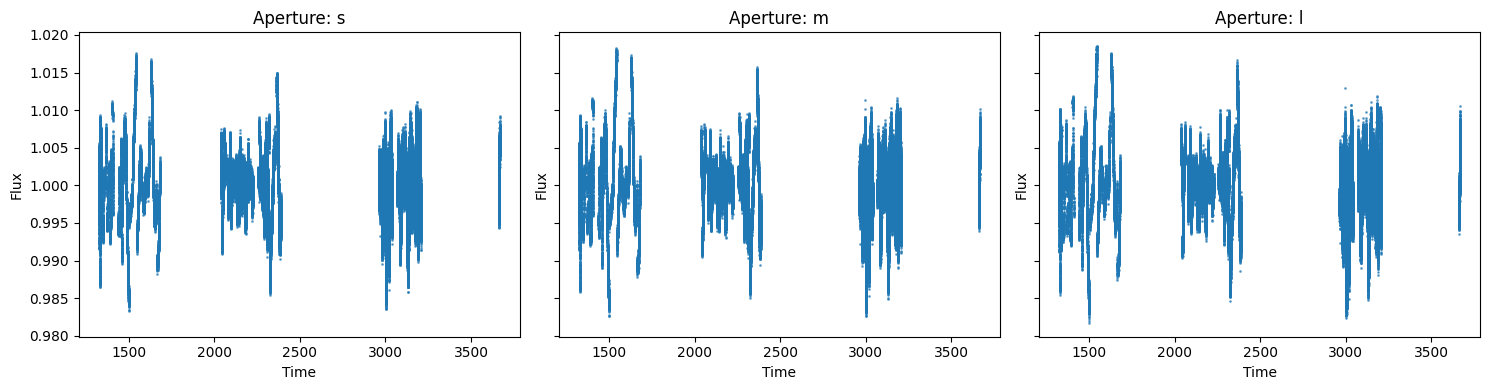

In [4]:
# Process TCE function call

# Step 1: Get aperturues
time, flux = get_lightcurve(tce['Astro ID'])
apertures = {
    's': get_lightcurve(tce['Astro ID'], aperture='s'),
    'm': get_lightcurve(tce['Astro ID'], aperture='m'),
    'l': get_lightcurve(tce['Astro ID'], aperture='l'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (label, (t, f)) in zip(axes, apertures.items()):
    ax.plot(t, f, '.', markersize=2, alpha=0.6)
    ax.set_title(f"Aperture: {label}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.show()

In [5]:
int(time.shape[0])//10

13600

Using: /pdo/users/pablomer/Astronet-Triage/light_curve_util/median_filter2.py
DEBUG enabled? 1
Has debug print? True


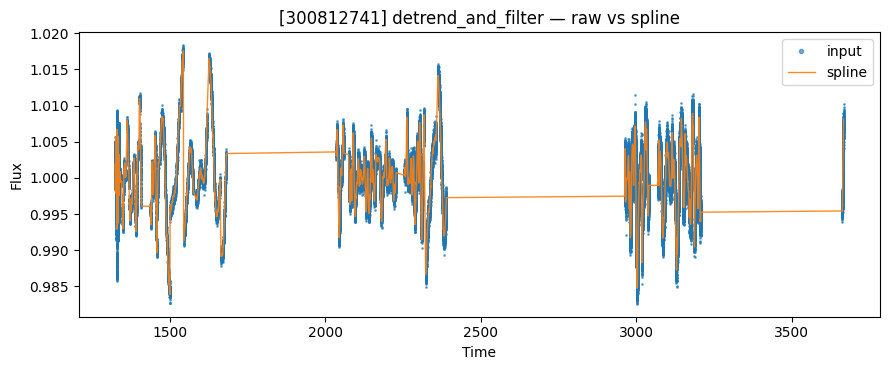

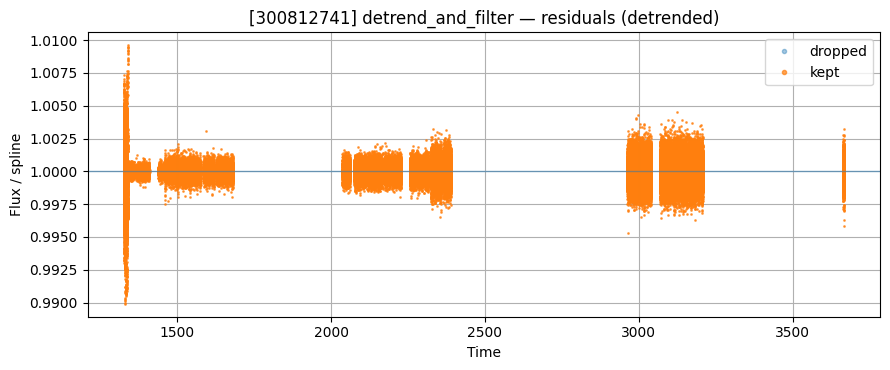

epoc: 1328.692690824254
duration: 0.1507261373615322
period: 11.30711901153312
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
detrended_flux: [1.00388796 1.00384088 1.00431211 ... 0.99972439 0.99908095 1.00131963]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]
raw_time [-5.6535009  -5.6533167  -5.65325404 ...  5.65326496  5.65343422
  5.65345769]
t [-5.6535009  -5.6533167  -5.65325404 ...  5.65326496  5.65343422
  5.65345769]
[new_binning DEBUG] cadence selection summary:
  bins all phase1: 201
  bins all phase2: 0
  bins mixed:      0
  points phase1:   186336
  points phase2:   0


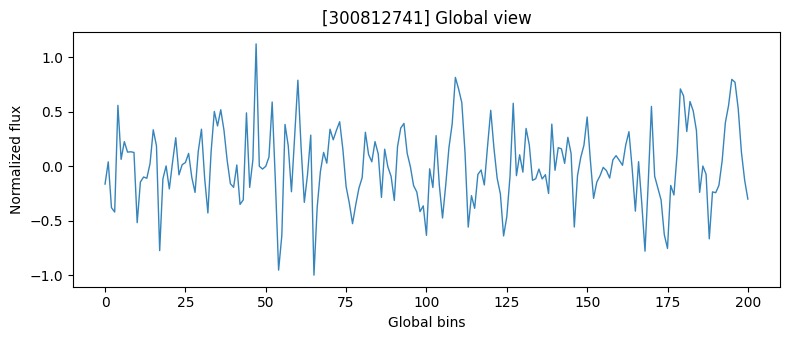

View values: [-1.63699378e-01  4.02342975e-02 -3.80147796e-01 -4.20430034e-01
  5.59252461e-01  6.35299659e-02  2.25924627e-01  1.29868796e-01
  1.32913060e-01  1.26849957e-01 -5.17841338e-01 -1.44649467e-01
 -9.87421046e-02 -1.10058122e-01  2.43689447e-02  3.34990006e-01
  1.87259605e-01 -7.74853050e-01 -1.16432916e-01  3.05167907e-03
 -2.08073640e-01  3.69387173e-02  2.62034069e-01 -7.87693052e-02
  1.45549845e-02  3.37505241e-02  1.18228823e-01 -1.03153592e-01
 -2.40023462e-01  1.36526715e-01  3.40510407e-01 -1.12394293e-01
 -4.28984684e-01  1.33200837e-01  5.03242088e-01  3.70261328e-01
  5.18939145e-01  3.31437874e-01  5.29731139e-02 -1.60322564e-01
 -1.93403086e-01  1.16694064e-02 -3.50417161e-01 -3.08847127e-01
  4.90288083e-01 -1.93923426e-01  5.86184912e-02  1.12362585e+00
  0.00000000e+00 -2.57426311e-02 -5.38798014e-04  8.42165786e-02
  5.89749254e-01 -1.40704052e-01 -9.53700394e-01 -6.36590163e-01
  3.83977128e-01  1.88195259e-01 -2.33757062e-01  2.87170500e-01
  7.90210532

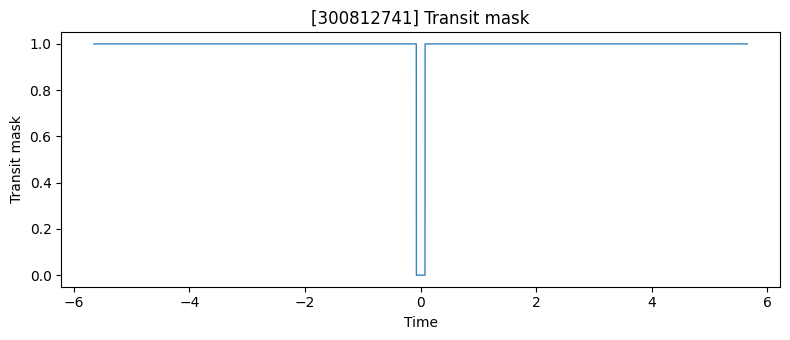

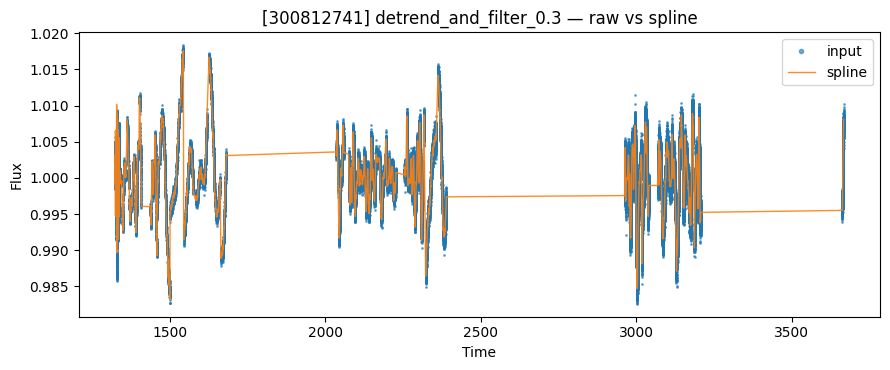

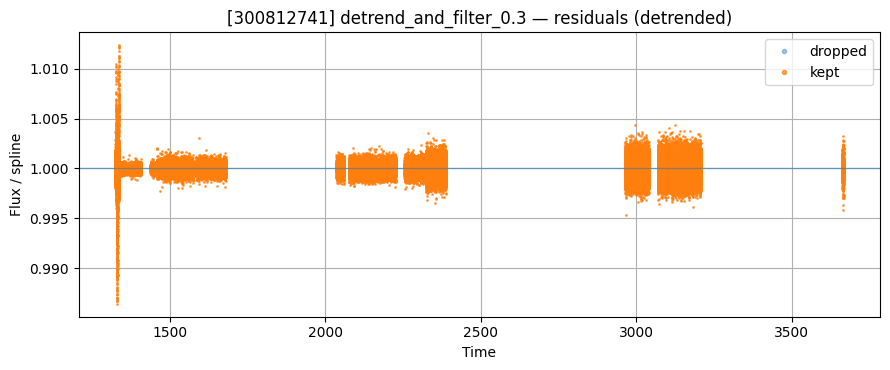

epoc: 1328.692690824254
duration: 0.1507261373615322
period: 11.30711901153312
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
detrended_flux: [1.00284278 1.00218185 1.0016883  ... 0.99975121 0.99910943 1.00135533]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]
raw_time [-5.6535009  -5.6533167  -5.65325404 ...  5.65326496  5.65343422
  5.65345769]
t [-5.6535009  -5.6533167  -5.65325404 ...  5.65326496  5.65343422
  5.65345769]
[new_binning DEBUG] cadence selection summary:
  bins all phase1: 201
  bins all phase2: 0
  bins mixed:      0
  points phase1:   186336
  points phase2:   0


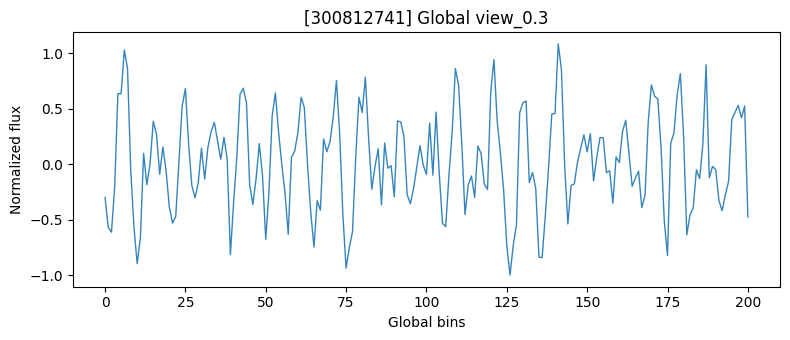

View values: [-3.00276079e-01 -5.69946432e-01 -6.12111244e-01 -2.05798653e-01
  6.35890867e-01  6.34869204e-01  1.02926557e+00  8.59391795e-01
 -5.90541723e-02 -5.66136565e-01 -8.96706892e-01 -6.62106912e-01
  9.73619000e-02 -1.85677421e-01  0.00000000e+00  3.85711524e-01
  2.71859106e-01 -9.05233401e-02  1.54369860e-01 -6.19135486e-02
 -3.85941264e-01 -5.31491269e-01 -4.69653116e-01  2.20243698e-02
  5.25221718e-01  6.81858504e-01  1.83504740e-01 -1.91522755e-01
 -3.03288812e-01 -1.68988529e-01  1.43984132e-01 -1.33048112e-01
  1.49257662e-01  2.92393500e-01  3.76332468e-01  2.12774852e-01
  4.48787400e-02  2.41788025e-01  4.72310426e-02 -8.15462344e-01
 -3.46508772e-01  6.39887148e-02  6.30797256e-01  6.84330747e-01
  5.54443761e-01 -1.86310254e-01 -3.63365707e-01 -1.29419260e-01
  1.85043411e-01 -1.07119518e-01 -6.76976603e-01 -2.51797388e-01
  4.36459050e-01  6.41726579e-01  2.87362888e-01 -2.15391811e-03
 -2.63271641e-01 -6.33329149e-01  6.07403294e-02  1.18553661e-01
  2.83295360

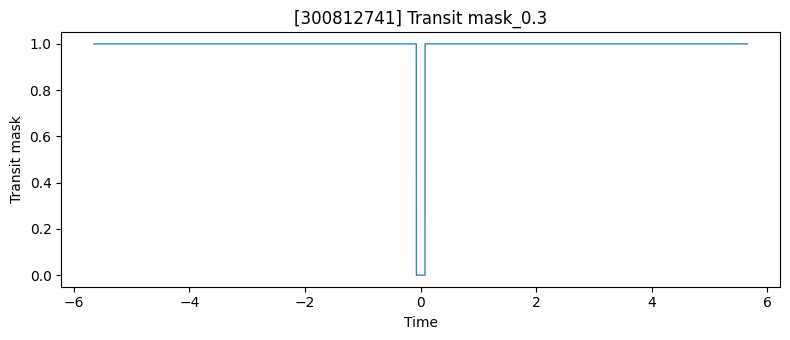

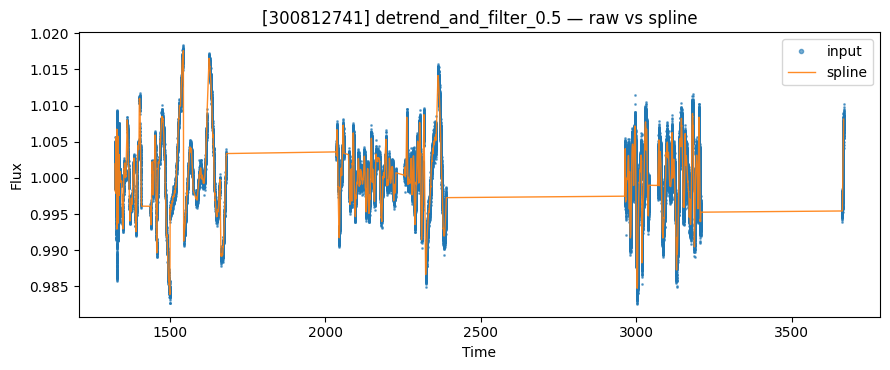

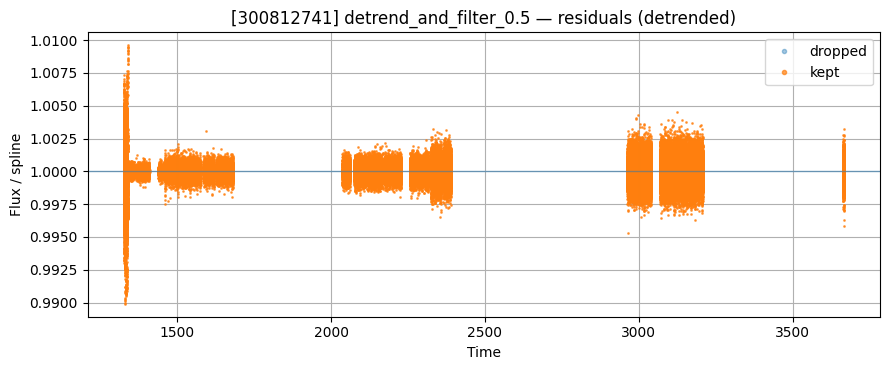

epoc: 1328.692690824254
duration: 0.1507261373615322
period: 11.30711901153312
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
detrended_flux: [1.00388796 1.00384088 1.00431211 ... 0.99972439 0.99908095 1.00131963]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3667.05893044 3667.06124529
 3667.0705047 ]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]
raw_time [-5.6535009  -5.6533167  -5.65325404 ...  5.65326496  5.65343422
  5.65345769]
t [-5.6535009  -5.6533167  -5.65325404 ...  5.65326496  5.65343422
  5.65345769]
[new_binning DEBUG] cadence selection summary:
  bins all phase1: 201
  bins all phase2: 0
  bins mixed:      0
  points phase1:   186336
  points phase2:   0


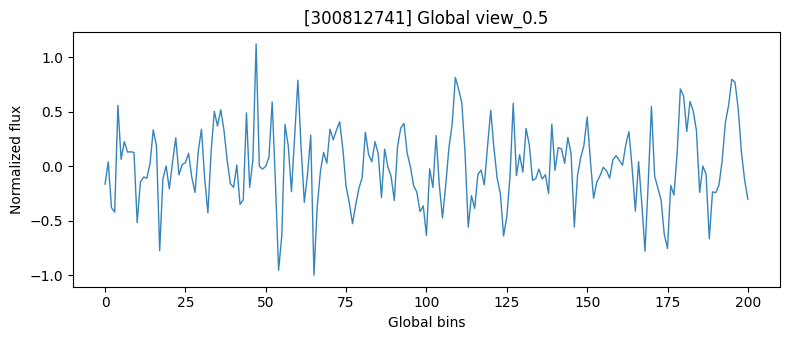

View values: [-1.63699378e-01  4.02342975e-02 -3.80147796e-01 -4.20430034e-01
  5.59252461e-01  6.35299659e-02  2.25924627e-01  1.29868796e-01
  1.32913060e-01  1.26849957e-01 -5.17841338e-01 -1.44649467e-01
 -9.87421046e-02 -1.10058122e-01  2.43689447e-02  3.34990006e-01
  1.87259605e-01 -7.74853050e-01 -1.16432916e-01  3.05167907e-03
 -2.08073640e-01  3.69387173e-02  2.62034069e-01 -7.87693052e-02
  1.45549845e-02  3.37505241e-02  1.18228823e-01 -1.03153592e-01
 -2.40023462e-01  1.36526715e-01  3.40510407e-01 -1.12394293e-01
 -4.28984684e-01  1.33200837e-01  5.03242088e-01  3.70261328e-01
  5.18939145e-01  3.31437874e-01  5.29731139e-02 -1.60322564e-01
 -1.93403086e-01  1.16694064e-02 -3.50417161e-01 -3.08847127e-01
  4.90288083e-01 -1.93923426e-01  5.86184912e-02  1.12362585e+00
  0.00000000e+00 -2.57426311e-02 -5.38798014e-04  8.42165786e-02
  5.89749254e-01 -1.40704052e-01 -9.53700394e-01 -6.36590163e-01
  3.83977128e-01  1.88195259e-01 -2.33757062e-01  2.87170500e-01
  7.90210532

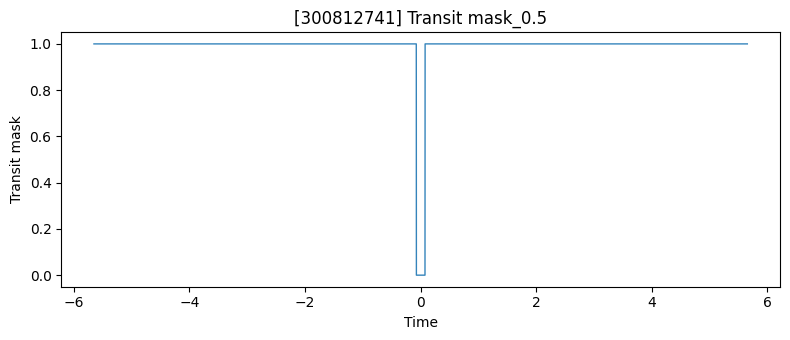

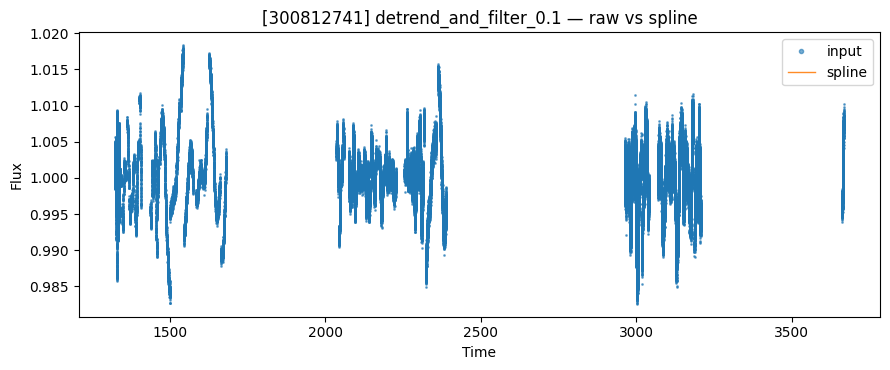

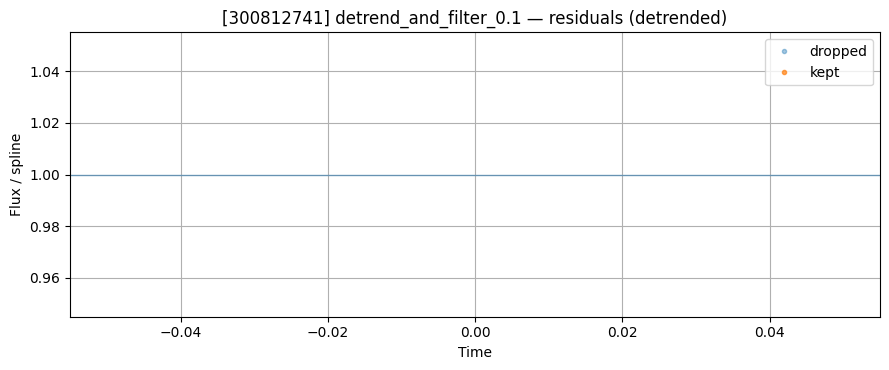

IndexError: index 0 is out of bounds for axis 0 with size 0

In [6]:
# Step 2: Generate standard views
from astronet.preprocess.preprocess import filter_outliers, get_spline_mask
from light_curve_util import keplersplinev2


import os, importlib, inspect
os.environ["ASTRONET_DEBUG_BINNING"] = "1"

import light_curve_util.median_filter2 as mf2
importlib.reload(mf2)  # pick up code + env var

print("Using:", mf2.__file__)
print("DEBUG enabled?", os.getenv("ASTRONET_DEBUG_BINNING"))

# Sanity: confirm the debug print exists in this loaded function
src = inspect.getsource(mf2.new_binning)
print("Has debug print?", "[new_binning DEBUG]" in src)

def detrend_and_filter_debug(
    tic_id, time, flux, period, epoch, duration, fixed_bkspace,
    *,
    plot=True,
    title_tag=""
):
    # 1) Build transit mask (in-transit = True)
    input_mask = get_spline_mask(time, period, epoch, duration)
    # 2) Fit spline
    spline_flux, metadata = keplersplinev2.choosekeplersplinev2(
        time,
        flux,
        input_mask=input_mask,
        fixed_bkspace=fixed_bkspace,
        return_metadata=True,
        maxiter=10
    )

    detrended_flux = flux / spline_flux

    # 3) Outlier filtering (keep the mask aligned with filtered arrays)
    detr_time, detr_flux, keep_mask = filter_outliers(time, detrended_flux, input_mask)

    # 4) Plot debug views
    if plot:
        tag = "" if fixed_bkspace is None else f"_{fixed_bkspace}"
        title = f"[{tic_id}] detrend_and_filter{tag}{title_tag}"

        # (a) Raw + spline
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[input_mask], flux[input_mask], ".", markersize=2, alpha=0.6, label="input")
        plt.plot(time, spline_flux, "-", linewidth=1.0, alpha=0.9, label="spline")
        plt.xlabel("Time")
        plt.ylabel("Flux")
        plt.title(f"{title} — raw vs spline")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()

        plt.show()

        # (b) Residuals / detrended, highlighting points dropped by outlier filter
        kept = np.isin(time, detr_time)
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[~kept], detrended_flux[~kept], ".", markersize=2, alpha=0.4, label="dropped")
        plt.plot(time[kept], detrended_flux[kept],   ".", markersize=2, alpha=0.7, label="kept")
        plt.axhline(1.0, lw=1, alpha=0.5)
        plt.xlabel("Time")
        plt.ylabel("Flux / spline")
        plt.title(f"{title} — residuals (detrended)")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()
        plt.grid(True)
        # plt.xticks(np.linspace(1200, 1500, 10))
        # plt.ylim(0.995, 1.005)
        plt.show()

    return detr_time, detr_flux, input_mask[np.isin(time, detr_time)]

def _debug_plot_global_view(tic, view, tag=""):
    plt.figure(figsize=(8, 3.5))
    x = np.arange(len(view))
    plt.plot(x, view, "-", linewidth=1.0, alpha=0.9)
    plt.xlabel("Global bins")
    plt.ylabel("Normalized flux")
    plt.title(f"[{tic}] Global view{tag}")
    plt.tight_layout()
    plt.show()

def build_global_views_with_debug(
    tic,
    time,
    flux,
    period,
    epoc,
    duration,
    bkspaces=(None, 0.3, 0.5,0.1,1,0.2),
):
    """
    Minimal pipeline:
      - detrend_and_filter
      - phase_fold_and_sort_light_curve
      - global_view
    Plus debug visualizations at each of the three steps.
    Returns: dict mapping tag -> fold_num (from the folded call).
    """
    fold_nums_out = {}

    for bkspace in bkspaces:
        tag = "" if bkspace is None else f"_{bkspace}"
        # period=period*2
        # duration=duration*2
        # 1) Detrend + filter
        detrended_time, detrended_flux, transit_mask = detrend_and_filter_debug(
            tic, time, flux, period, epoc, duration, bkspace
        )

        # #Clip to keep only the final 20% of the detrended_time
        # clip_idx = int(len(detrended_time) * 0.8)  # Keep last 20%
        # detrended_time = detrended_time[clip_idx:]
        # detrended_flux = detrended_flux[clip_idx:]
        # transit_mask = transit_mask[clip_idx:]


        while epoc < detrended_time[0]:
            epoc = epoc + period

        print(f"epoc: {epoc}")
        print(f"duration: {duration}")
        print(f"period: {period}")
        print(f"detrended_time: {detrended_time}")
        print(f"detrended_flux: {detrended_flux}")
        print(f"transit_mask: {transit_mask}")
        print(f"time: {time}")
        print(f"detrended_time: {detrended_time}")
        print(f"flux: {flux}")
        # 2) Phase-fold + sort
        folded_time, folded_flux, fold_num, tr_mask = preprocess.phase_fold_and_sort_light_curve(
            detrended_time, detrended_flux, transit_mask, period, epoc
        )
        fold_nums_out[tag or "_none"] = fold_num


        # 3) Global view on folded data
        view, std, mask, _, _ = preprocess.global_view(tic, folded_time, folded_flux, period)

        # Debug viz #3
        _debug_plot_global_view(tic, view, tag=tag)
        print('View values:',view)

        # Also plot the transit mask
        plt.figure(figsize=(8, 3.5))
        plt.plot(folded_time, tr_mask, "-", linewidth=1.0, alpha=0.9)
        plt.xlabel("Time")
        plt.ylabel("Transit mask")
        plt.title(f"[{tic}] Transit mask{tag}")
        plt.tight_layout()
        plt.show()

    return fold_nums_out

build_global_views_with_debug(tce['TIC ID'],  time, flux, tce.Per, tce.Epoc, tce.Dur)
